# Employee Attrition Analytics & Explainable Attrition Prediction

## Notebook 2: Data Quality Assessment

### Objective

The objective of this notebook is to evaluate the quality of the dataset by identifying missing values, duplicate records, incorrect data types, constant columns, outliers, and class imbalance. No preprocessing or data cleaning will be performed in this notebook.

## Import Libraries

Import the libraries required for data loading, analysis, and visualization.

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

Load the employee attrition dataset into a pandas DataFrame.

In [21]:
df = pd.read_csv("../data/employee_attrition.csv")


## Dataset Shape

### Objective

Confirm the number of rows and columns before performing quality checks.

In [22]:
df.shape

(1470, 35)

## Missing Values

### Objective

Check whether any columns contain missing values.

In [23]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [24]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent

Age                         0.0
Attrition                   0.0
BusinessTravel              0.0
DailyRate                   0.0
Department                  0.0
DistanceFromHome            0.0
Education                   0.0
EducationField              0.0
EmployeeCount               0.0
EmployeeNumber              0.0
EnvironmentSatisfaction     0.0
Gender                      0.0
HourlyRate                  0.0
JobInvolvement              0.0
JobLevel                    0.0
JobRole                     0.0
JobSatisfaction             0.0
MaritalStatus               0.0
MonthlyIncome               0.0
MonthlyRate                 0.0
NumCompaniesWorked          0.0
Over18                      0.0
OverTime                    0.0
PercentSalaryHike           0.0
PerformanceRating           0.0
RelationshipSatisfaction    0.0
StandardHours               0.0
StockOptionLevel            0.0
TotalWorkingYears           0.0
TrainingTimesLastYear       0.0
WorkLifeBalance             0.0
YearsAtC

### Observation

No missing values were found in the dataset. Therefore, no imputation is required.

## Duplicate Records

### Objective

Check whether duplicate employee records exist.

In [25]:
df.duplicated().sum()

np.int64(0)

## Data Types

### Objective

Verify that each column has the correct data type.

In [26]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Observation

The numerical columns are stored as integer values, while categorical columns are stored as objects. No incorrect data types were identified.

## Unique Values

### Objective

Inspect the unique values of all categorical columns to identify inconsistencies.

In [28]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].unique())
    print("-" * 50)


Attrition
['Yes' 'No']
--------------------------------------------------

BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
--------------------------------------------------

Department
['Sales' 'Research & Development' 'Human Resources']
--------------------------------------------------

EducationField
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
--------------------------------------------------

Gender
['Female' 'Male']
--------------------------------------------------

JobRole
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
--------------------------------------------------

MaritalStatus
['Single' 'Married' 'Divorced']
--------------------------------------------------

Over18
['Y']
--------------------------------------------------

OverTime
['Yes' 'No']
------------------------

### Observation

The categorical columns contain consistent category names. No spelling mistakes or inconsistent capitalization were observed.

## Frequency of Categories

### Objective

Count the occurrence of each category in the categorical columns.

In [29]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].value_counts())
    print("=" * 60)


Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     673


### Observation

The frequency counts help verify category consistency and identify rare categories.

## Constant Columns

### Objective

Identify columns containing only one unique value.

In [30]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [31]:
constant_columns = [col for col in df.columns if df[col].nunique() == 1]

constant_columns

['EmployeeCount', 'Over18', 'StandardHours']

### Observation

The following constant columns were identified:

- EmployeeCount
- Over18
- StandardHours

These columns do not contribute useful information for prediction and may be removed during preprocessing.

## Class Imbalance

### Objective

Examine the distribution of the target variable (Attrition).

In [32]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [33]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

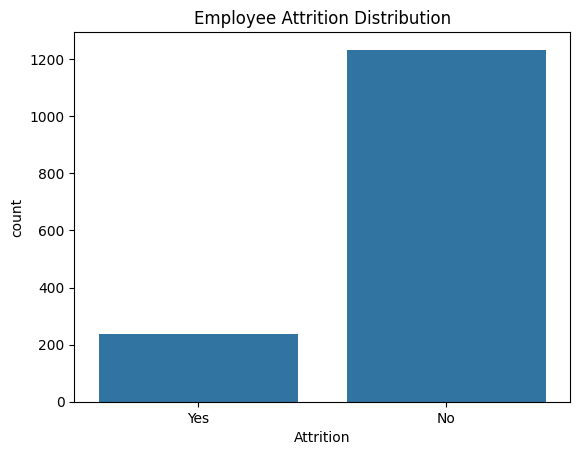

In [34]:
sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.show()

### Observation

The dataset is imbalanced.

Approximately 83% of employees stayed with the company, while 17% left. This imbalance should be considered during model evaluation.

## Numerical Summary

### Objective

Review summary statistics of numerical features to identify unusual values.

In [35]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Observation

The numerical summary shows no obvious unrealistic values.

# Outlier Detection

## Objective

Identify potential outliers in numerical features using boxplots.

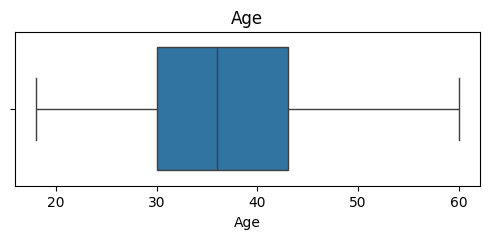

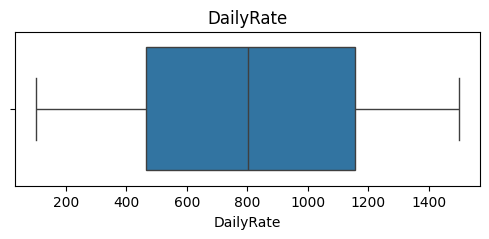

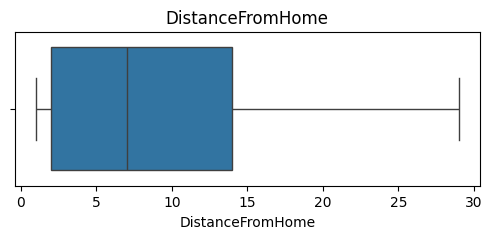

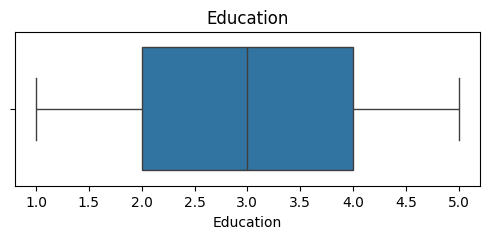

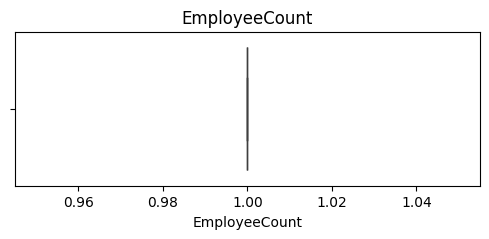

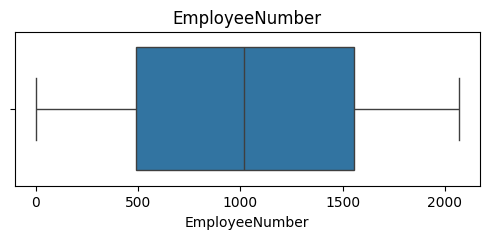

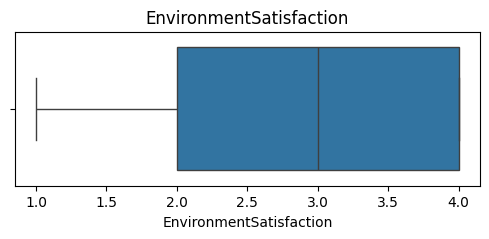

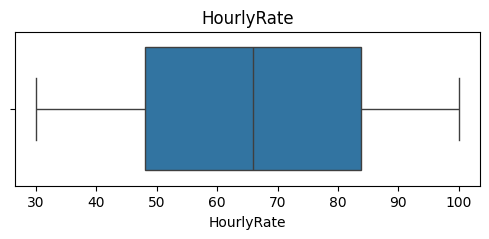

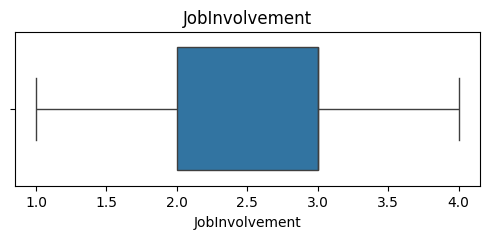

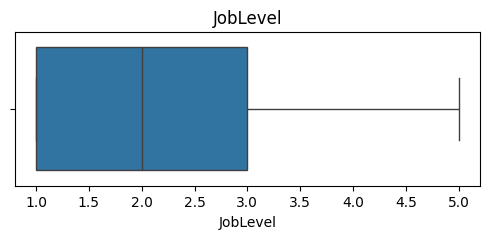

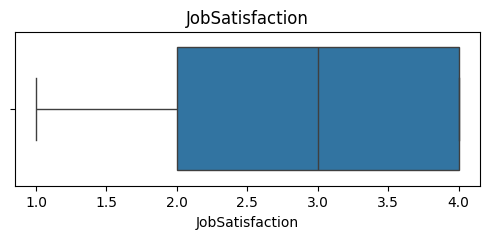

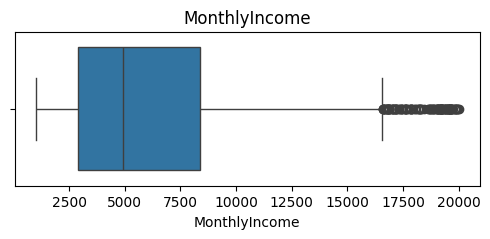

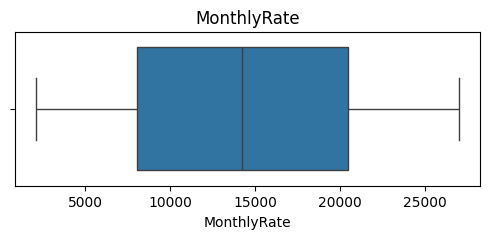

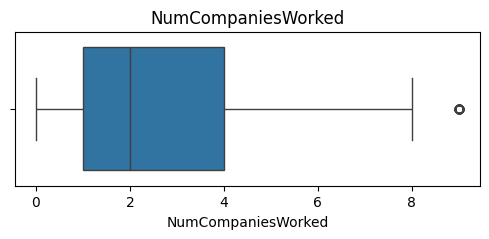

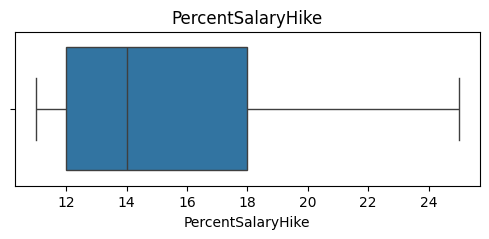

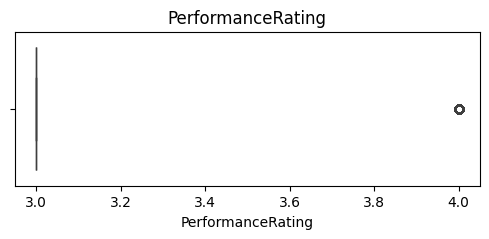

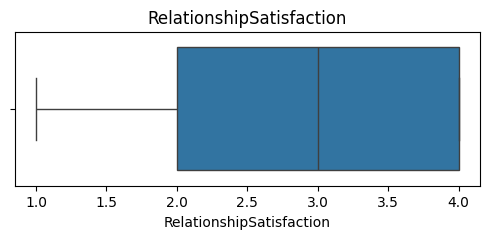

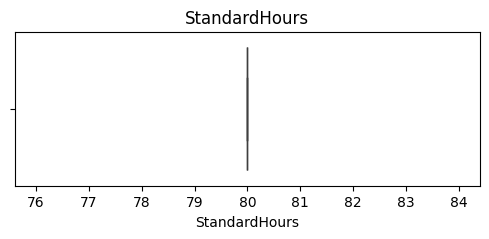

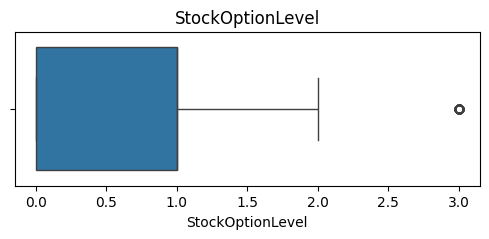

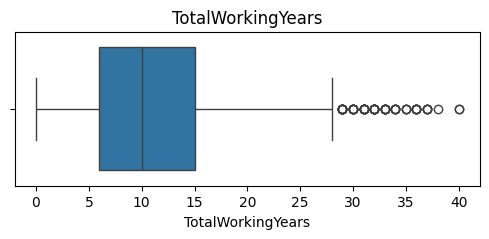

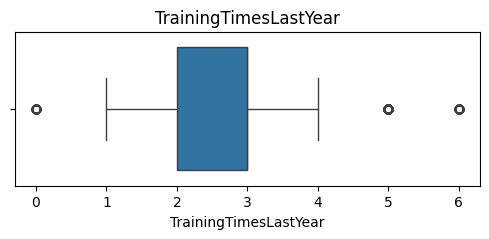

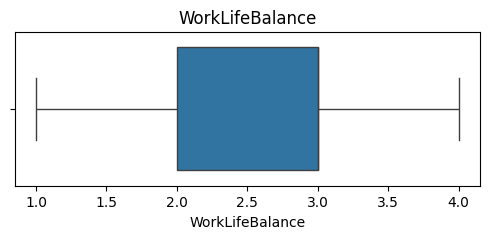

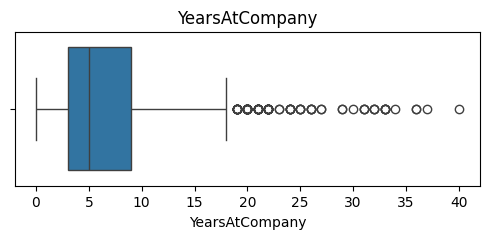

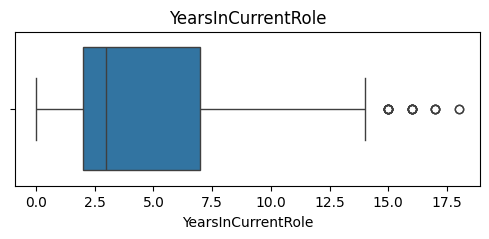

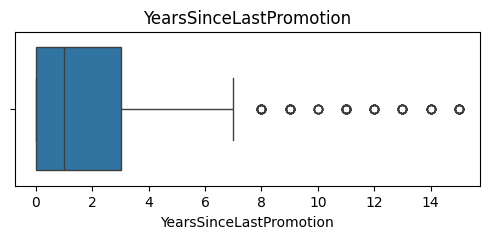

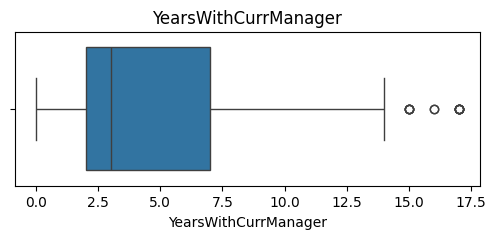

In [36]:
numerical_columns=df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Observation

Outliers are present in some numerical features. These may represent valid observations and will be evaluated during preprocessing.

# Correlation Analysis

## Objective

Analyze relationships between numerical features using a correlation heatmap.

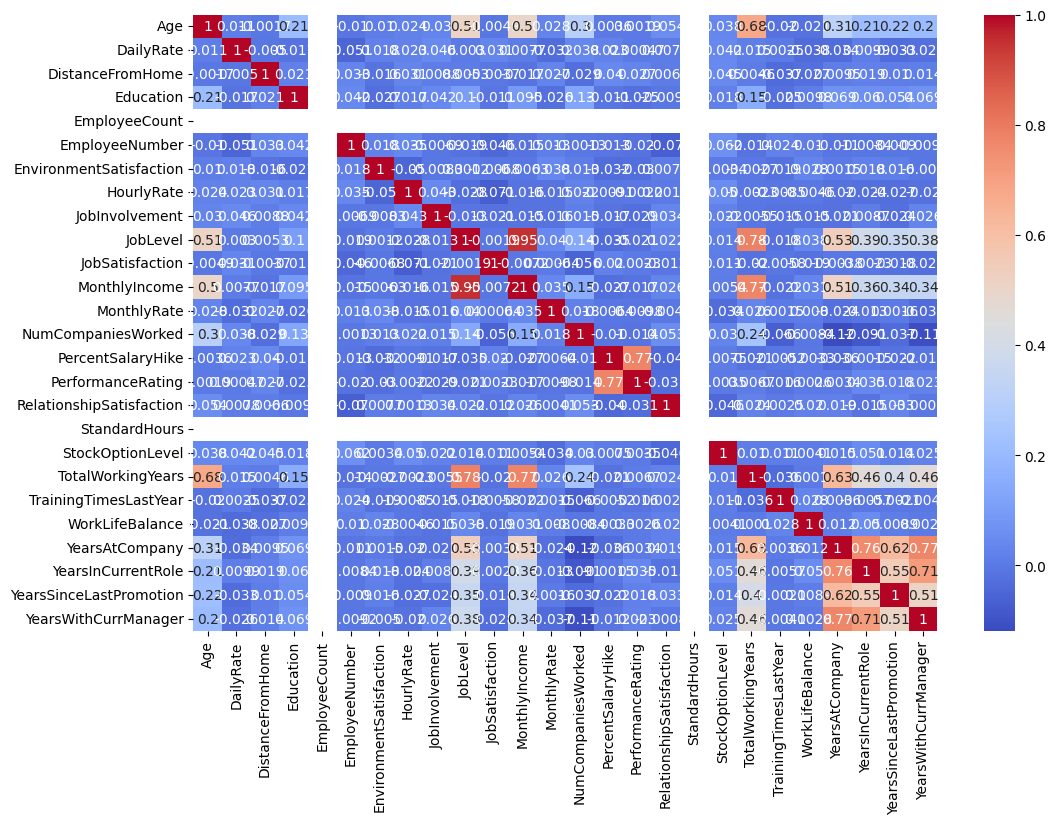

In [37]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## Observation

Some numerical features show moderate to high correlation, which may be considered during feature selection.

# Dataset Quality Summary

## Objective

Summarize the overall results of the data quality assessment.

In [38]:
quality_summary = pd.DataFrame({
    "Quality Check": [
        "Missing Values",
        "Duplicate Rows",
        "Incorrect Data Types",
        "Constant Columns",
        "Outliers",
        "Class Imbalance"
    ],
    "Result": [
        "None",
        "0",
        "None",
        "EmployeeCount, Over18, StandardHours",
        "Present",
        "Yes (83% vs 17%)"
    ]
})

quality_summary

,Quality Check,Result
0,Missing Values,None
1,Duplicate Rows,0
2,Incorrect Data Types,None
3,Constant Columns,"EmployeeCount, Over18, StandardHours"
4,Outliers,Present
5,Class Imbalance,Yes (83% vs 17%)


## Observation

The dataset has good overall quality with only minor issues to address during preprocessing.

# Final Dataset Quality Report

## Objective

Provide a concise summary of the dataset quality assessment.

# Observation

The dataset contains **1,470 employee records** and **35 features**.

- No missing values were detected.
- No duplicate rows were found.
- Data types are appropriate for all columns.
- Three constant columns (**EmployeeCount**, **Over18**, and **StandardHours**) were identified. These do not add predictive value and can be removed during data cleaning.
- Several numerical features show outliers (e.g., **MonthlyIncome**), but these likely represent genuine high-income employees rather than data errors.
- The target variable is imbalanced, with significantly more employees staying than leaving the company. This should be considered during model evaluation.